<center><H1>Prosjektoppgave</H1><br>Henting av data fra NVDB API og opplasting av data til en database i SQL server express

In [4]:
import requests
import pyodbc


# Connection til SQL Server
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\SQLEXPRESS;"
    "DATABASE=Case_NVDB;"
    "Trusted_Connection=yes;"
)
cursor = conn.cursor()
cursor.fast_executemany = True  # forbedrer ytelse

# Oppretter API kall med parametre og headers. Paginering med antallsbegrensing er helt nødvendig for å ikke kræsje API. 

url = "https://nvdbapiles.atlas.vegvesen.no/vegobjekter/915"

req_headers = {
    "Accept": "application/json",
    "X-Client": "python-script"
}

# initialiserer variabler for paginering
start = None
previous_start = None

while True:
    req_params = {
        "inkluder": "egenskaper,lokasjon",
        "srid": 5973,
        "segmentering": False,
        "trafikantgruppe": "K",
        "fylke": 50,
        "endret_etter": "2018-01-01T12:13:01",
        "antall": 200,
    }    

    # legg til start hvis finnes
    if start is not None:
        req_params["start"] = start

    #  API Get-kall med timeout dersom API mot formodning svarer tregt
    response = requests.get(
        url,
        params=req_params,
        headers=req_headers,
        timeout=30
    )
    response.raise_for_status()
    data = response.json() # data hentes som JSON

    objekter = data.get("objekter", [])

    # hvis det ikke finnes objekter bryt ut av løkken
    if not objekter:
        break
    
    # pakk ut innholdet i objektene og gjør strukturen flat. Egenskaper er en undertabell i objektet, og flates ut. 
    
    for obj in objekter:
        obj_id = obj.get("id")
        vegnummer = None
        vegkategori = None
        fase = None

        for eg in obj.get("egenskaper", []):
            navn = eg.get("navn")
            verdi = eg.get("verdi")

            if navn == "Vegnummer":
                vegnummer = verdi
            elif navn == "Vegkategori":
                vegkategori = verdi
            elif navn == "Fase":
                fase = verdi

        # henter lokasjonsdata. Er usikker på hvor interessant det er å ha med fylke her. Ettersom ID for fylket er sendt som parameter 
        # i kallet er det kanskje litt unødvendig.
        
        lokasjon = obj.get("lokasjon", {})

        fylker = lokasjon.get("fylker", [])
            
        if fylker:
                fylke_id = fylker[0]
            else:
                fylke_id = None
        
        lengde = lokasjon.get("lengde")

        # Fyller dimensjonstabellen i databasen med data fra API
        cursor.execute("""
            INSERT INTO DimVegobjekt (
                NVDB_ID,
                Vegnummer,
                Vegkategori,
                Fase,
                Fylke_ID,
                Lengde
            )
            VALUES (?, ?, ?, ?, ?, ?)
        """,
        obj_id,
        vegnummer,
        vegkategori,
        fase,
        fylke_id,
        lengde
        )

        # fyller hjelpetabellen (staging( stedfestinger med data fra API 
        for s in obj.get("lokasjon", {}).get("stedfestinger", []):
            cursor.execute("""
                INSERT INTO Staging_Vegobjekt_Stedfesting (
                    Vegobjekt_ID,
                    Veglenkesekvens_ID,
                    Startpos,
                    Sluttpos
                )
                VALUES (?, ?, ?, ?)
            """,
            obj_id,
            s.get("veglenkesekvensid"),
            s.get("startposisjon"),
            s.get("sluttposisjon")
            )

    # commit etter hver side med 200 objekter
    conn.commit()

    # ivaretar at pagineringen skal fungere. Henter token fra neste i metadata. Hvvis det er tomt brytes løkken. Hvis det er 
    # lik det forrige antar man også at man er kommet til veis ende i spørringen og at det ikke er mer å hente. 
    
    neste = data.get("metadata", {}).get("neste")
    if not neste:
        break
 
    previous_start = start
    start = neste.get("start")

    if start == previous_start:
        print("Stopper: start-token gjentas")
        break

conn.close()

<center><h3>Lesing av data fra database med enkel visualiserinng av en spørring</h3>


C:\Users\s14013\AppData\Local\Temp\ipykernel_21732\1434627285.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


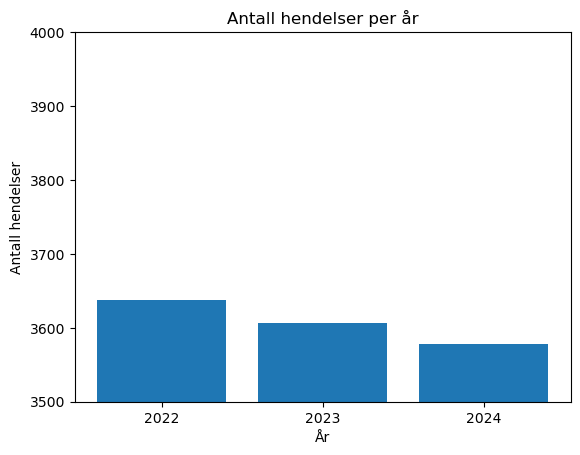

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\SQLEXPRESS;"
    "DATABASE=Case_NVDB;"
    "Trusted_Connection=yes;"
)
# gjør en veldig simpel spørring for å vise hendelser fordelt utover årene 
query = """
SELECT [Year], COUNT(*) as Antall
FROM FactHendelser
GROUP BY [Year]
ORDER BY [Year]
"""

df = pd.read_sql(query, conn)
df["Year"] = df["Year"].astype(str) # måtte castes til string for å ikke vise rare tallverdier på x aksen

plt.bar(df["Year"], df["Antall"])
plt.title("Antall hendelser per år")
plt.xlabel("År")
plt.ylabel("Antall hendelser")
plt.ylim(3500,4000)
plt.show()